<a href="https://colab.research.google.com/github/ninobronw/BPALM-TOOL-IMPLEMENTATION/blob/main/SuperKart_Notebook_CLEAN_stream.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [7]:
# Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 flask==3.1.1 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [8]:
import warnings
warnings.filterwarnings("ignore")

# Libraries for data manipulation
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

# Libraries for ensemble regressors
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries for evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# Pipeline and preprocessing
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

# Model serialization
import joblib

# OS and API
import os
import requests

# XGBoost
import xgboost as xgb

# **Loading the dataset**

In [9]:
data = pd.read_csv("//content/sample_data/SuperKart.csv")

# Preview the first 5 rows
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


# **Data Overview**

In [10]:
# Dataset dimensions
print("Dimensions:", data.shape)

# Column information
data.info()

# Descriptive statistics
print(data.describe())

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

Dimensions: (8763, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB
       Product_Weight 

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

count    8763.000000
mean     3464.003640
std      1065.630494
min        33.000000
25%      2761.715000
50%      3452.340000
75%      4145.165000
max      8000.000000
Name: Product_Store_Sales_Total, dtype: float64


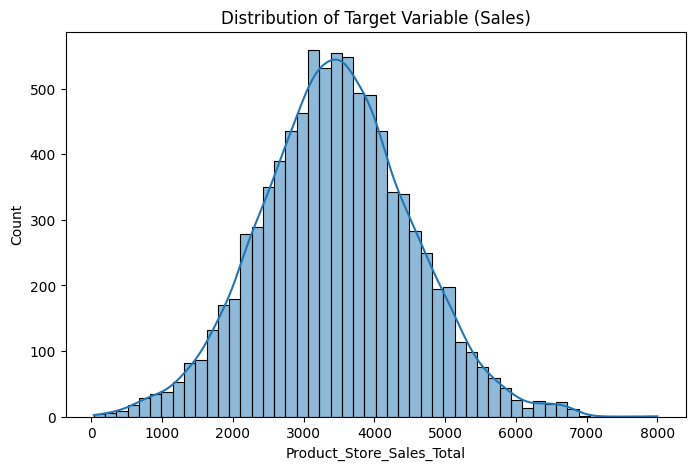

In [11]:
# Target variable: distribution and statistics
print(data['Product_Store_Sales_Total'].describe())
plt.figure(figsize=(8, 5))
sns.histplot(data['Product_Store_Sales_Total'], bins=50, kde=True)
plt.title("Distribution of Target Variable (Sales)")
plt.show()

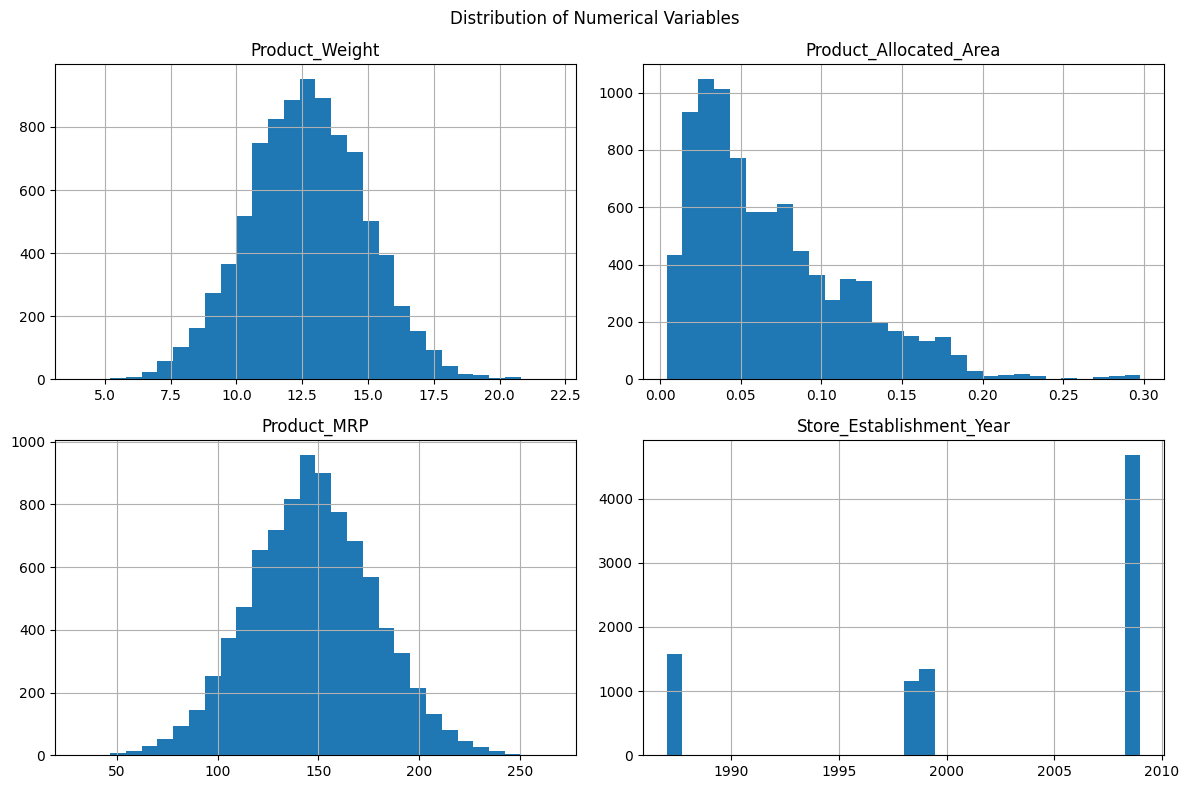

In [12]:
# Numerical variables: histogram per variable
numerical_cols = [c for c in data.select_dtypes(include='number').columns
                  if c != 'Product_Store_Sales_Total']
data[numerical_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Distribution of Numerical Variables")
plt.tight_layout()
plt.show()

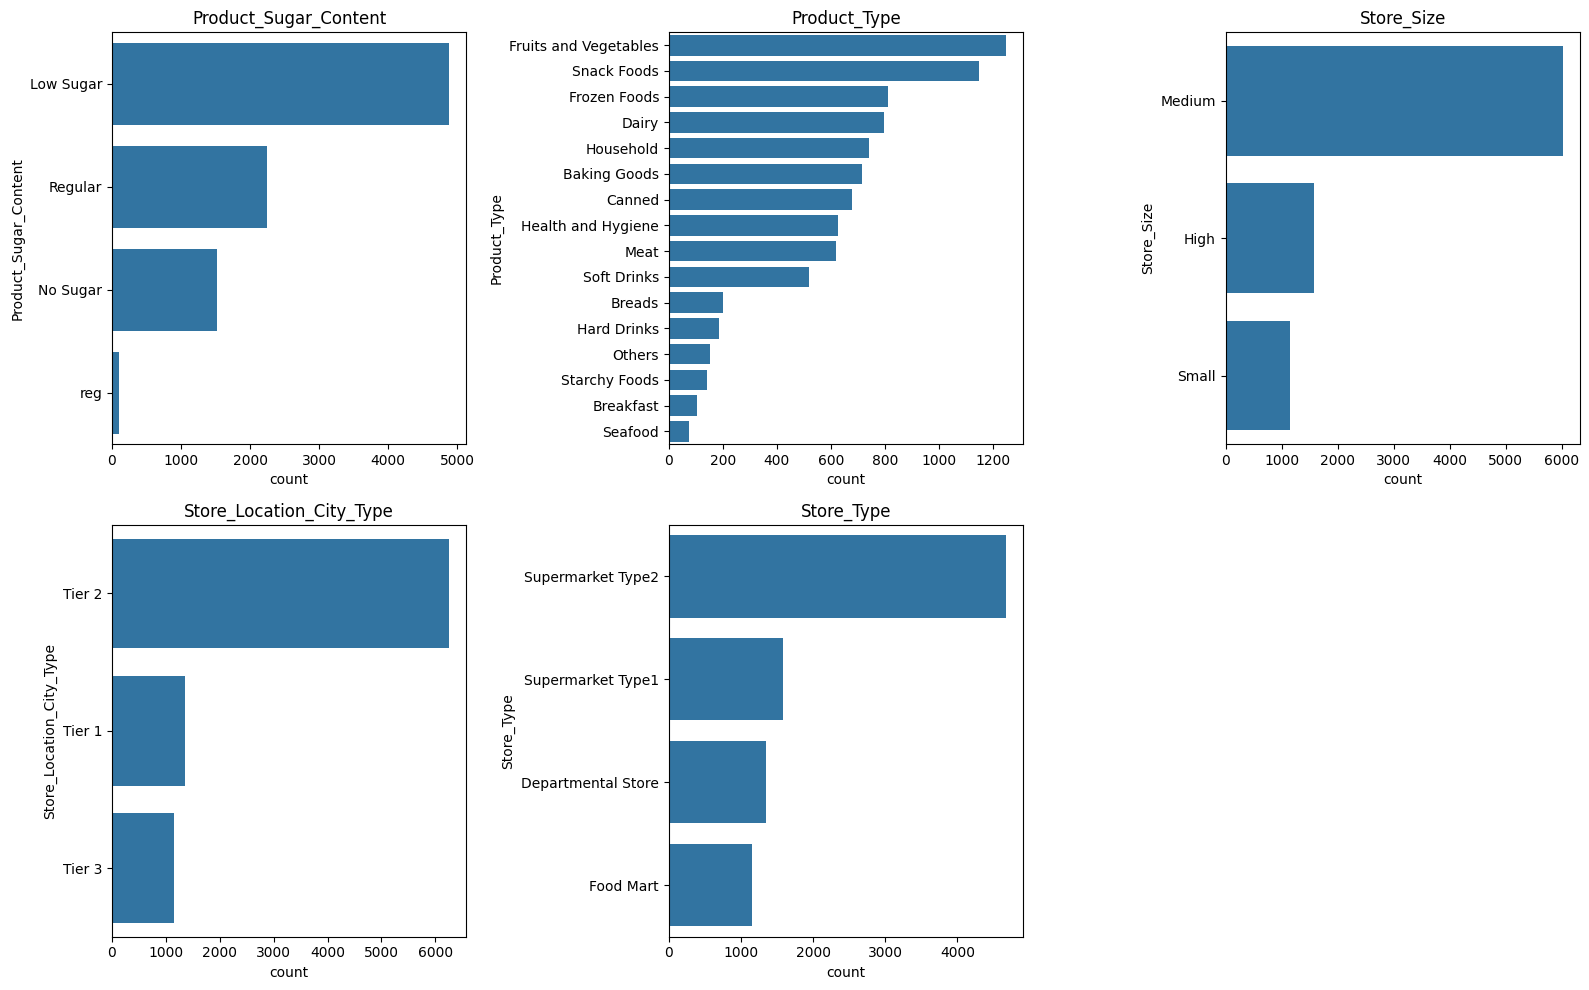

In [13]:
# Categorical variables: countplot per variable (excluding identifiers)
categorical_cols = [c for c in data.select_dtypes(include='object').columns
                    if c not in ['Product_Id', 'Store_Id']]
plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=col, data=data, order=data[col].value_counts().index)
    plt.title(col)
plt.tight_layout()
plt.show()

## Bivariate Analysis

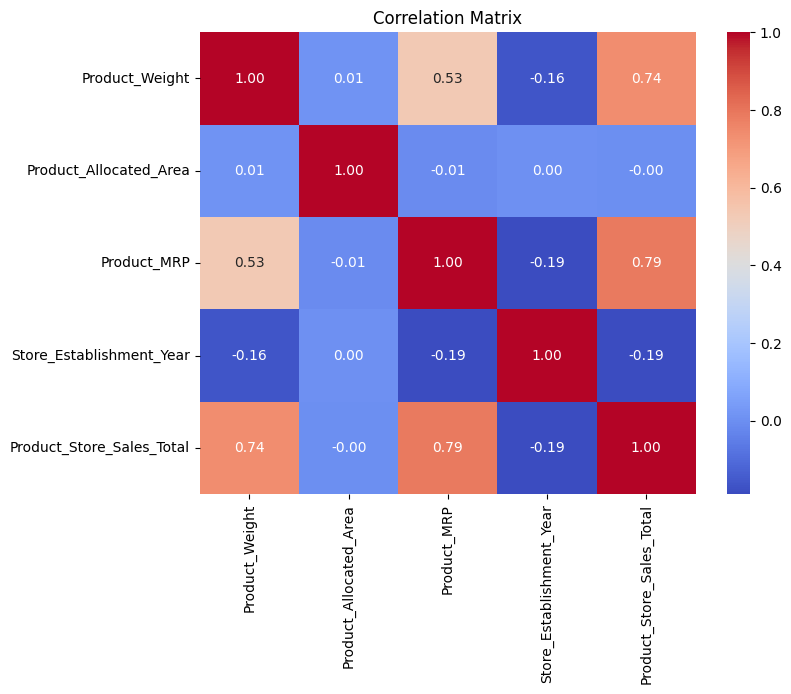

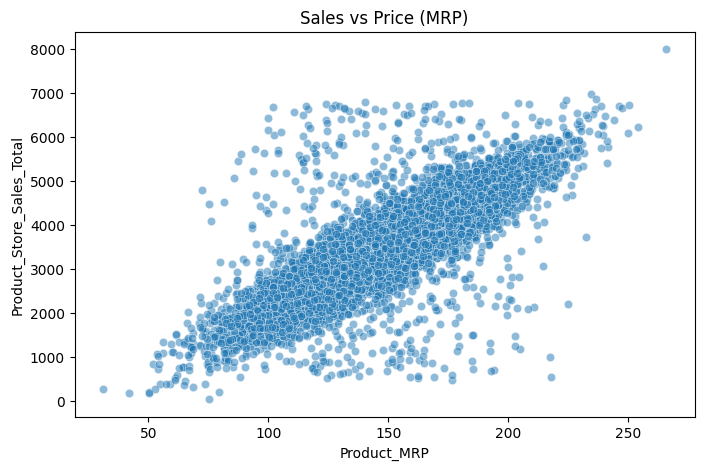

Sales / Price correlation: 0.788


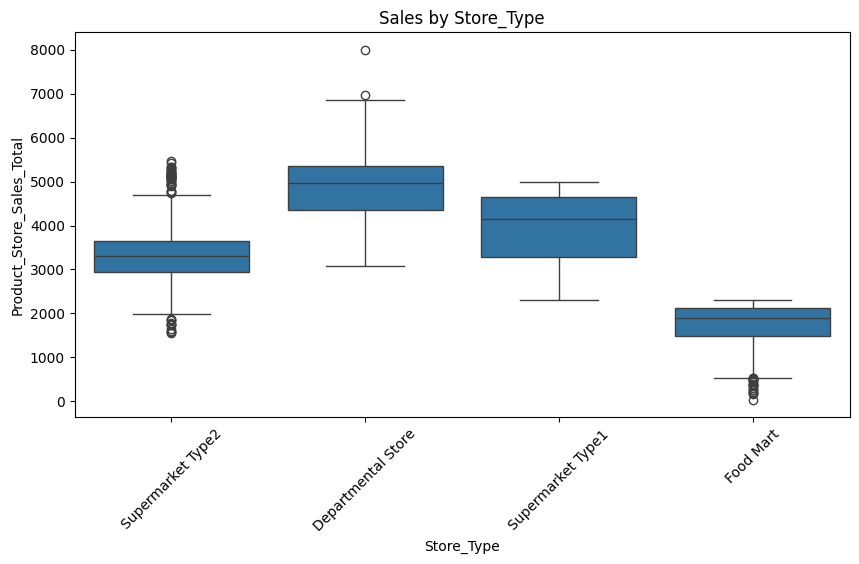

Store_Type
Departmental Store    4946.966323
Supermarket Type1     3923.778802
Supermarket Type2     3299.312111
Food Mart             1762.942465
Name: Product_Store_Sales_Total, dtype: float64


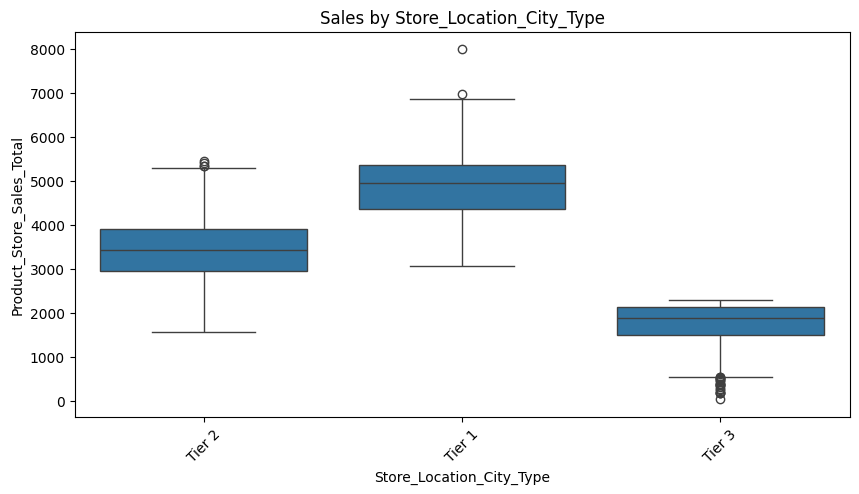

Store_Location_City_Type
Tier 1    4946.966323
Tier 2    3457.473109
Tier 3    1762.942465
Name: Product_Store_Sales_Total, dtype: float64


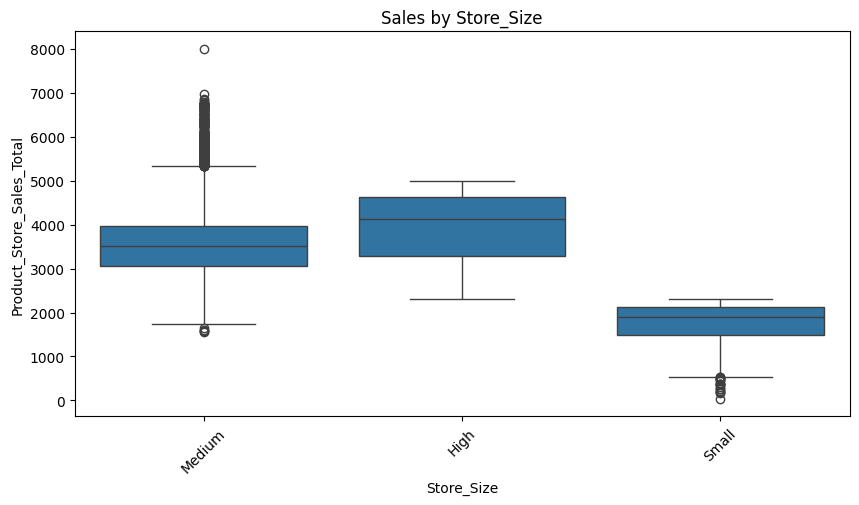

Store_Size
High      3923.778802
Medium    3668.222573
Small     1762.942465
Name: Product_Store_Sales_Total, dtype: float64


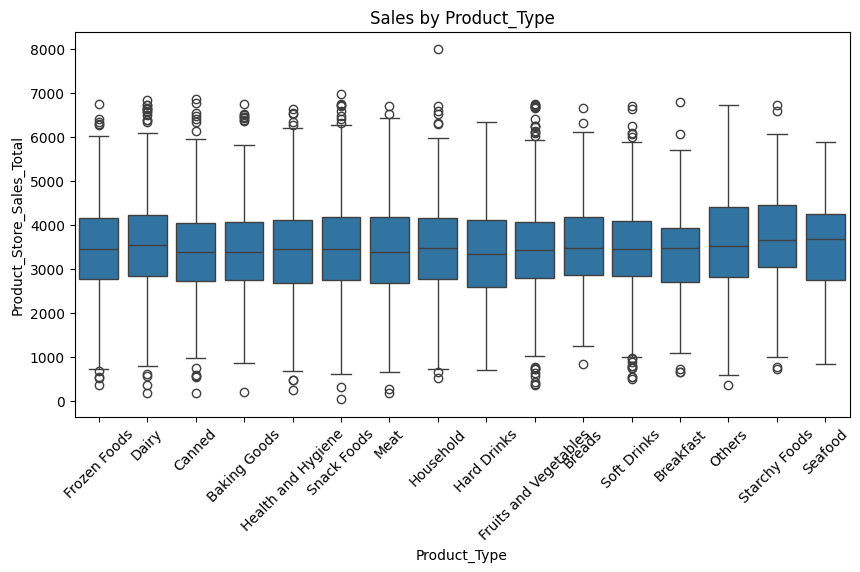

Product_Type
Starchy Foods            3679.251418
Others                   3586.068212
Seafood                  3584.263684
Breads                   3574.711200
Dairy                    3532.560352
Snack Foods              3471.711880
Household                3465.865095
Frozen Foods             3464.834562
Soft Drinks              3462.513911
Health and Hygiene       3445.393646
Meat                     3445.326764
Fruits and Vegetables    3443.421353
Baking Goods             3425.958101
Breakfast                3416.324623
Canned                   3397.463383
Hard Drinks              3364.594731
Name: Product_Store_Sales_Total, dtype: float64


In [14]:
# 1. Correlation between numerical variables
plt.figure(figsize=(8, 6))
sns.heatmap(data.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

# 2. Sales vs Price (key numerical relationship)
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Product_MRP', y='Product_Store_Sales_Total', data=data, alpha=0.5)
plt.title("Sales vs Price (MRP)")
plt.show()
print("Sales / Price correlation:",
      round(data['Product_MRP'].corr(data['Product_Store_Sales_Total']), 3))

# 3. Sales by main categorical variables
for col in ['Store_Type', 'Store_Location_City_Type', 'Store_Size', 'Product_Type']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=col, y='Product_Store_Sales_Total', data=data)
    plt.title(f"Sales by {col}")
    plt.xticks(rotation=45)
    plt.show()
    print(data.groupby(col)['Product_Store_Sales_Total'].mean().sort_values(ascending=False))

# **Data Preprocessing**

In [15]:
# --- Handling missing values ---
# Option 1: drop incomplete rows (if few rows affected)
data_clean = data.dropna()

# Option 2: imputation
# Numerical variables -> median
num_imputer = SimpleImputer(strategy='median')
data[['Product_Weight', 'Product_MRP']] = num_imputer.fit_transform(data[['Product_Weight', 'Product_MRP']])

# Categorical variables -> most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
data[['Product_Type', 'Store_Type']] = cat_imputer.fit_transform(data[['Product_Type', 'Store_Type']])

# **Model Building**

## Define functions for Model Evaluation

In [16]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [17]:
# Define column groups
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

# Define transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Full pipeline (preprocessing + model)
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42))
])

# Train/test split
X = data.drop('Product_Store_Sales_Total', axis=1)
y = data['Product_Store_Sales_Total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training
model_pipeline.fit(X_train, y_train)

# Evaluation
y_pred = model_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"Test set MAE: {mae:.2f}")

Test set MAE: 121.17


In [18]:
df_perf = model_performance_regression(model_pipeline, X_test, y_test)
display(df_perf)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,288.535209,121.171635,0.927037,0.926576,0.044356


The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

[0]	validation_0-mae:764.29131
[1]	validation_0-mae:695.77975
[2]	validation_0-mae:634.97026
[3]	validation_0-mae:583.91318
[4]	validation_0-mae:532.67797
[5]	validation_0-mae:487.53958
[6]	validation_0-mae:450.86599
[7]	validation_0-mae:418.27520
[8]	validation_0-mae:384.99925
[9]	validation_0-mae:357.78666
[10]	validation_0-mae:334.30161
[11]	validation_0-mae:309.74481
[12]	validation_0-mae:287.33920
[13]	validation_0-mae:267.83546
[14]	validation_0-mae:252.53909
[15]	validation_0-mae:239.80142
[16]	validation_0-mae:226.05406
[17]	validation_0-mae:214.32619
[18]	validation_0-mae:206.44256
[19]	validation_0-mae:200.23269
[20]	validation_0-mae:194.83388
[21]	validation_0-mae:190.67825
[22]	validation_0-mae:185.12353
[23]	validation_0-mae:181.57116
[24]	validation_0-mae:176.55139
[25]	validation_0-mae:170.58514
[26]	validation_0-mae:165.63659
[27]	validation_0-mae:161.31086
[28]	validation_0-mae:156.69228
[29]	validation_0-mae:152.92314
[30]	validation_0-mae:151.19873
[31]	validation_0-

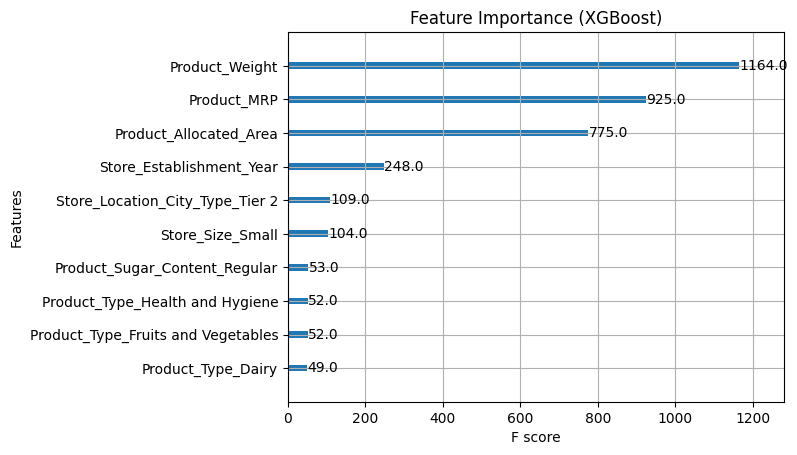

In [19]:
# Access the preprocessor from the previously defined model_pipeline
preprocessor = model_pipeline.named_steps['preprocessor']

# Transform X_train and X_test using the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Initialize the XGBoost model
model_xgb = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=10,
    eval_metric='mae'
)

# Training with evaluation set
eval_set = [(X_test_processed, y_test)]
model_xgb.fit(
    X_train_processed, y_train,
    eval_set=eval_set,
    verbose=True
)

# Predictions
y_pred_xgb = model_xgb.predict(X_test_processed)

# Evaluation
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost - MAE: {mae_xgb:.2f}, R2: {r2_xgb:.2f}")

# Feature importance
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

num_feature_names = numeric_cols
cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = list(num_feature_names) + list(cat_feature_names)

model_xgb.get_booster().feature_names = all_feature_names

xgb.plot_importance(model_xgb, max_num_features=10)
plt.title("Feature Importance (XGBoost)")
plt.show()

Random Forest - MAE: 114.06, R2: 0.93


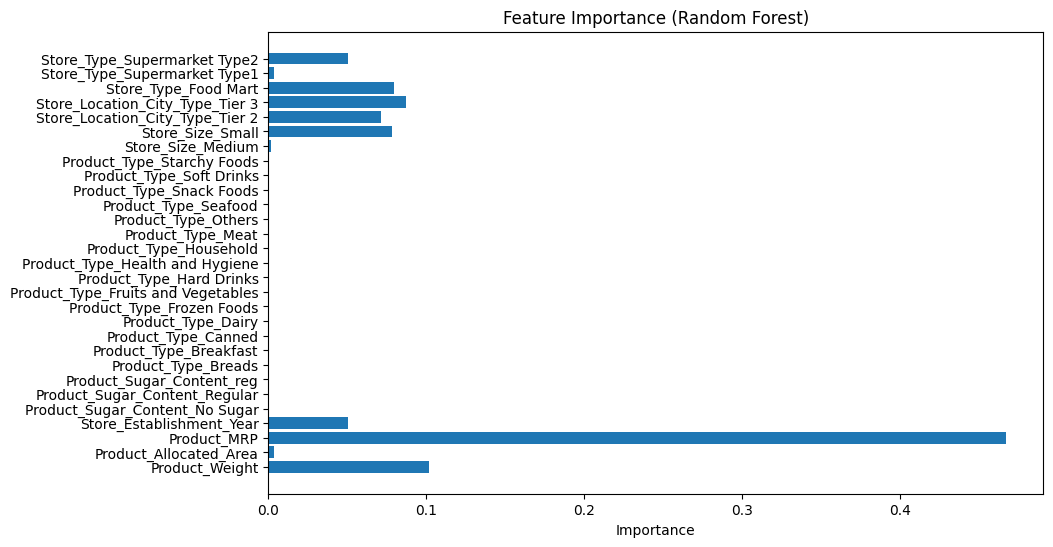

In [20]:
# Initialize Random Forest model
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train on preprocessed data
model_rf.fit(X_train_processed, y_train)

# Predictions on preprocessed data
y_pred_rf = model_rf.predict(X_test_processed)

# Evaluation
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest - MAE: {mae_rf:.2f}, R2: {r2_rf:.2f}")

# Feature importance
importances = model_rf.feature_importances_
if 'all_feature_names' not in globals():
    numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
    categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
    preprocessor = model_pipeline.named_steps['preprocessor']
    num_feature_names = numeric_cols
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_cols)
    all_feature_names = list(num_feature_names) + list(cat_feature_names)

features = all_feature_names

plt.figure(figsize=(10, 6))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

In [21]:
warnings.filterwarnings("ignore")

# Gradient Boosting (scikit-learn)
model_gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=6)
model_gb.fit(X_train_processed, y_train)

# Prédictions pour Gradient Boosting
y_pred_gb = model_gb.predict(X_test_processed)

# AdaBoost (scikit-learn)
model_ada = AdaBoostRegressor(n_estimators=100, learning_rate=0.1)
model_ada.fit(X_train_processed, y_train)

# Prédictions pour AdaBoost
y_pred_ada = model_ada.predict(X_test_processed)


In [22]:
# Evaluate Gradient Boosting
df_perf_gb = model_performance_regression(model_gb, X_test_processed, y_test)
print("Gradient Boosting Regressor Performance:")
display(df_perf_gb)

# Evaluate AdaBoost
df_perf_ada = model_performance_regression(model_ada, X_test_processed, y_test)
print("\nAdaBoost Regressor Performance:")
display(df_perf_ada)

Gradient Boosting Regressor Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,294.409218,122.077706,0.924036,0.922757,0.043783



AdaBoost Regressor Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,475.526984,361.890461,0.801821,0.798486,0.124503


In [23]:
print("=" * 60)
print("CROSS-VALIDATION (5-Fold) - All Models")
print("=" * 60)

model_xgb_cv = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mae'
)

models_cv = {
    'XGBoost': model_xgb_cv,
    'Random Forest': model_rf,
    'Gradient Boosting': model_gb,
    'AdaBoost': model_ada
}

cv_results = []

for name, mdl in models_cv.items():
    scores = cross_val_score(mdl, X_train_processed, y_train, cv=5, scoring='neg_mean_absolute_error')
    mae_scores = -scores
    cv_results.append({'Model': name, 'CV MAE Mean': round(mae_scores.mean(), 2), 'CV MAE Std': round(mae_scores.std(), 2)})
    print(f"{name:25s} | Mean MAE: {mae_scores.mean():.2f} (+/- {mae_scores.std():.2f})")

cv_df = pd.DataFrame(cv_results).sort_values('CV MAE Mean')
print("\nCross-Validation Ranking:")
display(cv_df)

CROSS-VALIDATION (5-Fold) - All Models
XGBoost                   | Mean MAE: 129.65 (+/- 4.09)
Random Forest             | Mean MAE: 115.45 (+/- 3.64)
Gradient Boosting         | Mean MAE: 122.62 (+/- 5.09)
AdaBoost                  | Mean MAE: 366.15 (+/- 11.36)

Cross-Validation Ranking:


,Model,CV MAE Mean,CV MAE Std
1,Random Forest,115.45,3.64
2,Gradient Boosting,122.62,5.09
0,XGBoost,129.65,4.09
3,AdaBoost,366.15,11.36


# **Model Performance Improvement - Hyperparameter Tuning**

In [24]:
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    params,
    n_iter=20,
    cv=5,
    scoring='neg_mean_squared_error',
    random_state=42
)
search.fit(X_train_processed, y_train)
print("Best parameters:", search.best_params_)

Best parameters: {'n_estimators': 100, 'min_samples_split': 10, 'max_depth': 6, 'learning_rate': 0.05}


In [25]:
# Train Gradient Boosting with best parameters
model_gb_tuned = GradientBoostingRegressor(**search.best_params_, random_state=42)
model_gb_tuned.fit(X_train_processed, y_train)

# Evaluate tuned Gradient Boosting
df_perf_gb_tuned = model_performance_regression(model_gb_tuned, X_test_processed, y_test)
print("Tuned Gradient Boosting Regressor Performance:")
display(df_perf_gb_tuned)

# Compare all model performances
model_performances = pd.DataFrame({
    'Model': ['XGBoost Pipeline', 'XGBoost Standalone', 'Random Forest',
              'Gradient Boosting (Untuned)', 'AdaBoost', 'Gradient Boosting (Tuned)'],
    'RMSE': [
        df_perf['RMSE'].iloc[0],
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        df_perf_gb['RMSE'].iloc[0],
        df_perf_ada['RMSE'].iloc[0],
        df_perf_gb_tuned['RMSE'].iloc[0]
    ],
    'MAE': [
        df_perf['MAE'].iloc[0],
        mae_xgb,
        mae_rf,
        df_perf_gb['MAE'].iloc[0],
        df_perf_ada['MAE'].iloc[0],
        df_perf_gb_tuned['MAE'].iloc[0]
    ],
    'R-squared': [
        df_perf['R-squared'].iloc[0],
        r2_xgb,
        r2_rf,
        df_perf_gb['R-squared'].iloc[0],
        df_perf_ada['R-squared'].iloc[0],
        df_perf_gb_tuned['R-squared'].iloc[0]
    ],
    'Adj. R-squared': [
        df_perf['Adj. R-squared'].iloc[0],
        adj_r2_score(X_test_processed, y_test, y_pred_xgb),
        adj_r2_score(X_test_processed, y_test, y_pred_rf),
        df_perf_gb['Adj. R-squared'].iloc[0],
        df_perf_ada['Adj. R-squared'].iloc[0],
        df_perf_gb_tuned['Adj. R-squared'].iloc[0]
    ],
    'MAPE': [
        df_perf['MAPE'].iloc[0],
        mean_absolute_percentage_error(y_test, y_pred_xgb),
        mean_absolute_percentage_error(y_test, y_pred_rf),
        df_perf_gb['MAPE'].iloc[0],
        df_perf_ada['MAPE'].iloc[0],
        df_perf_gb_tuned['MAPE'].iloc[0]
    ]
})

print("\nModel Performance Comparison:")
display(model_performances.sort_values(by='MAE'))

Tuned Gradient Boosting Regressor Performance:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,280.502629,116.993708,0.931043,0.929882,0.042776



Model Performance Comparison:


,Model,RMSE,MAE,R-squared,Adj. R-squared,MAPE
2,Random Forest,282.883814,114.059765,0.929867,0.928686,0.040263
5,Gradient Boosting (Tuned),280.502629,116.993708,0.931043,0.929882,0.042776
0,XGBoost Pipeline,288.535209,121.171635,0.927037,0.926576,0.044356
3,Gradient Boosting (Untuned),294.409218,122.077706,0.924036,0.922757,0.043783
1,XGBoost Standalone,290.203848,124.305266,0.926190,0.924948,0.045724
4,AdaBoost,475.526984,361.890461,0.801821,0.798486,0.124503


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [26]:
# Create directory for backend files
if not os.path.exists('backend_files'):
    os.makedirs('backend_files')

# Select the best model based on lowest MAE
best_model_name = model_performances.sort_values(by='MAE').iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Random Forest has the lowest MAE, so we save it as the final model
final_model = model_rf

# Serialize the model and preprocessor
model_filename = 'backend_files/random_forest_model.joblib'
preprocessor_filename = 'backend_files/preprocessor.joblib'

joblib.dump(final_model, model_filename)
joblib.dump(preprocessor, preprocessor_filename)
print(f"Model '{best_model_name}' saved to '{model_filename}'")
print(f"Preprocessor saved to '{preprocessor_filename}'")

Best model: Random Forest
Model 'Random Forest' saved to 'backend_files/random_forest_model.joblib'
Preprocessor saved to 'backend_files/preprocessor.joblib'


In [27]:
# Also save as model.pkl for local Flask testing in Colab
joblib.dump(model_rf, 'model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Model and preprocessor saved as model.pkl and preprocessor.pkl for local testing.")

Model and preprocessor saved as model.pkl and preprocessor.pkl for local testing.


### Deployment - **Backend**

**Flask Web Framework - Local Testing in Colab**

In [28]:
"""
Flask Backend for SuperKart Sales Forecasting Model
This API serves predictions from the trained ML model
"""
from flask import Flask, request, jsonify
import joblib
import numpy as np
import pandas as pd
import os
import threading

app = Flask(__name__)

try:
    model = joblib.load('model.pkl')
    preprocessor = joblib.load('preprocessor.pkl')
    print("Model and preprocessor loaded successfully")
except FileNotFoundError:
    print("Model files not found. Make sure model.pkl and preprocessor.pkl exist.")
    model = None
    preprocessor = None

@app.route('/', methods=['GET'])
def home():
    return jsonify({'status': 'API is running', 'model': 'SuperKart Sales Forecasting', 'version': '1.0'}), 200

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({'error': 'No data provided'}), 400
        input_df = pd.DataFrame([data])
        if preprocessor is not None:
            X_processed = preprocessor.transform(input_df)
        else:
            return jsonify({'error': 'Preprocessor not available'}), 500
        if model is not None:
            prediction = model.predict(X_processed)[0]
            return jsonify({'prediction': float(prediction), 'input_data': data, 'status': 'success'}), 200
        else:
            return jsonify({'error': 'Model not available'}), 500
    except Exception as e:
        return jsonify({'error': str(e), 'status': 'failed'}), 400

@app.route('/predict_batch', methods=['POST'])
def predict_batch():
    try:
        data = request.get_json()
        records = data.get('records', [])
        if not records:
            return jsonify({'error': 'No records provided'}), 400
        input_df = pd.DataFrame(records)
        if preprocessor is not None:
            X_processed = preprocessor.transform(input_df)
        else:
            return jsonify({'error': 'Preprocessor not available'}), 500
        if model is not None:
            predictions = model.predict(X_processed)
            return jsonify({'predictions': [float(p) for p in predictions], 'num_records': len(records), 'status': 'success'}), 200
        else:
            return jsonify({'error': 'Model not available'}), 500
    except Exception as e:
        return jsonify({'error': str(e), 'status': 'failed'}), 400

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy', 'model_loaded': model is not None, 'preprocessor_loaded': preprocessor is not None}), 200

@app.errorhandler(404)
def not_found(error):
    return jsonify({'error': 'Endpoint not found'}), 404

@app.errorhandler(500)
def server_error(error):
    return jsonify({'error': 'Internal server error'}), 500

# Run Flask in a background thread so it doesn't block the Colab kernel
def run_flask():
    app.run(host='0.0.0.0', port=5000, debug=False, use_reloader=False)

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()
print("Flask API running in background on http://127.0.0.1:5000")

Model and preprocessor loaded successfully
Flask API running in background on http://127.0.0.1:5000


In [29]:
import requests
import time
time.sleep(2)

# Test data with the correct dataset columns
test_data = {
    "Product_Id": "FD001",
    "Product_Weight": 10.5,
    "Product_Sugar_Content": "Low Sugar",
    "Product_Allocated_Area": 0.05,
    "Product_Type": "Frozen Foods",
    "Product_MRP": 150.0,
    "Store_Id": "OUT001",
    "Store_Establishment_Year": 2009,
    "Store_Size": "Medium",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Supermarket Type1"
}

response = requests.post("http://127.0.0.1:5000/predict", json=test_data)
print("Status:", response.status_code)
print("Response:", response.json())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [26/Jul/2026 21:54:45] "POST /predict HTTP/1.1" 200 -


Status: 200
Response: {'input_data': {'Product_Allocated_Area': 0.05, 'Product_Id': 'FD001', 'Product_MRP': 150.0, 'Product_Sugar_Content': 'Low Sugar', 'Product_Type': 'Frozen Foods', 'Product_Weight': 10.5, 'Store_Establishment_Year': 2009, 'Store_Id': 'OUT001', 'Store_Location_City_Type': 'Tier 2', 'Store_Size': 'Medium', 'Store_Type': 'Supermarket Type1'}, 'prediction': 3869.0025423350266, 'status': 'success'}


## **Backend Dependencies File (requirements.txt)**

In [30]:
%%writefile backend_files/requirements.txt
flask==3.1.1
joblib==1.4.2
numpy==2.0.2
pandas==2.2.2
scikit-learn==1.6.1
gunicorn==23.0.0

Writing backend_files/requirements.txt


## **Backend Dockerfile**

In [31]:
%%writefile backend_files/Dockerfile
FROM python:3.12-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 7860

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "app:app"]

Writing backend_files/Dockerfile


# **Setting up the Backend for Deployment on Render**

In [32]:
# Create the render.yaml configuration file for Render deployment
with open('backend_files/render.yaml', 'w') as f:
    f.write("""services:
  - type: web
    name: superkart-backend
    runtime: python
    buildCommand: pip install -r requirements.txt
    startCommand: gunicorn app:app --bind 0.0.0.0:$PORT
""")
print("render.yaml created in backend_files/")
!ls -la backend_files/

render.yaml created in backend_files/
total 5400
drwxr-xr-x 2 root root    4096 Jul 26 21:54 .
drwxr-xr-x 1 root root    4096 Jul 26 21:54 ..
-rw-r--r-- 1 root root     166 Jul 26 21:54 Dockerfile
-rw-r--r-- 1 root root    6361 Jul 26 21:54 preprocessor.joblib
-rw-r--r-- 1 root root 5493745 Jul 26 21:54 random_forest_model.joblib
-rw-r--r-- 1 root root     178 Jul 26 21:54 render.yaml
-rw-r--r-- 1 root root      91 Jul 26 21:54 requirements.txt


**Note:** To deploy the backend on Render (free tier):
1. Create a GitHub repository named `superkart-backend`
2. Upload all files from the `backend_files/` directory to the repository
3. Go to [render.com](https://render.com) and create a free account
4. Click **New > Web Service** and connect your GitHub repository
5. Render will auto-detect the configuration. Select the **Free** plan and click **Deploy**
6. You will get a URL like `https://superkart-backend.onrender.com`

# **Downloading Backend Files for Deployment**

In [33]:
%%writefile backend_files/app.py
"""
Flask Backend for SuperKart Sales Forecasting Model
"""
from flask import Flask, request, jsonify
import joblib
import numpy as np
import pandas as pd
import os

app = Flask(__name__)

try:
    model = joblib.load('random_forest_model.joblib')
    preprocessor = joblib.load('preprocessor.joblib')
    print("Model and preprocessor loaded successfully")
except FileNotFoundError:
    print("Model files not found.")
    model = None
    preprocessor = None

@app.route('/', methods=['GET'])
def home():
    return jsonify({'status': 'API is running', 'model': 'SuperKart Sales Forecasting', 'version': '1.0'}), 200

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json()
        if not data:
            return jsonify({'error': 'No data provided'}), 400
        input_df = pd.DataFrame([data])
        if preprocessor is not None:
            X_processed = preprocessor.transform(input_df)
        else:
            return jsonify({'error': 'Preprocessor not available'}), 500
        if model is not None:
            prediction = model.predict(X_processed)[0]
            return jsonify({'prediction': float(prediction), 'input_data': data, 'status': 'success'}), 200
        else:
            return jsonify({'error': 'Model not available'}), 500
    except Exception as e:
        return jsonify({'error': str(e), 'status': 'failed'}), 400

@app.route('/predict_batch', methods=['POST'])
def predict_batch():
    try:
        data = request.get_json()
        records = data.get('records', [])
        if not records:
            return jsonify({'error': 'No records provided'}), 400
        input_df = pd.DataFrame(records)
        if preprocessor is not None:
            X_processed = preprocessor.transform(input_df)
        else:
            return jsonify({'error': 'Preprocessor not available'}), 500
        if model is not None:
            predictions = model.predict(X_processed)
            return jsonify({'predictions': [float(p) for p in predictions], 'num_records': len(records), 'status': 'success'}), 200
        else:
            return jsonify({'error': 'Model not available'}), 500
    except Exception as e:
        return jsonify({'error': str(e), 'status': 'failed'}), 400

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'healthy', 'model_loaded': model is not None, 'preprocessor_loaded': preprocessor is not None}), 200

@app.errorhandler(404)
def not_found(error):
    return jsonify({'error': 'Endpoint not found'}), 404

@app.errorhandler(500)
def server_error(error):
    return jsonify({'error': 'Internal server error'}), 500

if __name__ == '__main__':
    port = int(os.environ.get('PORT', 10000))
    app.run(host='0.0.0.0', port=port)

Writing backend_files/app.py


**Download the backend files as a zip to upload to GitHub:**

In [34]:
!zip -r superkart-backend.zip backend_files/
from google.colab import files
files.download('superkart-backend.zip')
print("Download the zip, extract it, and push all files to your GitHub repository.")

  adding: backend_files/ (stored 0%)
  adding: backend_files/requirements.txt (deflated 12%)
  adding: backend_files/app.py (deflated 70%)
  adding: backend_files/preprocessor.joblib (deflated 66%)
  adding: backend_files/random_forest_model.joblib (deflated 66%)
  adding: backend_files/render.yaml (deflated 26%)
  adding: backend_files/Dockerfile (deflated 11%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download the zip, extract it, and push all files to your GitHub repository.


### **Deployment - Frontend**

The frontend is built with Streamlit and deployed on Streamlit Cloud (free).

**Steps to deploy:**
1. Create a GitHub repository named `superkart-frontend`
2. Upload the files from `frontend_files/` to the repository
3. Go to [share.streamlit.io](https://share.streamlit.io) and sign in with GitHub
4. Click **New app**, select your repository, set **Main file** to `app.py`, and click **Deploy**

In [35]:
os.makedirs('frontend_files', exist_ok=True)

In [36]:
%%writefile frontend_files/app.py
"""
Streamlit Frontend for SuperKart Sales Forecasting
"""
import streamlit as st
import requests
import pandas as pd

# Backend API URL - replace with your Render deployment URL
API_URL = "https://superkart-backend.onrender.com"

st.set_page_config(page_title="SuperKart Sales Forecasting", layout="wide")
st.title("SuperKart Sales Forecasting")
st.markdown("Predict sales revenue for SuperKart retail outlets")

# Single prediction form
st.header("Single Prediction")

col1, col2, col3 = st.columns(3)

with col1:
    product_weight = st.number_input("Product Weight", min_value=1.0, max_value=25.0, value=12.0)
    product_sugar = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
    product_area = st.number_input("Product Allocated Area", min_value=0.001, max_value=0.5, value=0.05)
    product_mrp = st.number_input("Product MRP", min_value=30.0, max_value=270.0, value=150.0)

with col2:
    product_type = st.selectbox("Product Type", [
        "Frozen Foods", "Dairy", "Canned", "Baking Goods", "Health and Hygiene",
        "Snack Foods", "Meat", "Hard Drinks", "Soft Drinks", "Bread", "Breakfast",
        "Fruits and Vegetables", "Household", "Seafood", "Starchy Foods", "Others"
    ])
    store_id = st.selectbox("Store ID", ["OUT001", "OUT002", "OUT003", "OUT004", "OUT005",
                                          "OUT006", "OUT007", "OUT008", "OUT009", "OUT010"])
    store_year = st.number_input("Store Establishment Year", min_value=1985, max_value=2025, value=2009)

with col3:
    store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
    store_location = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
    store_type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2",
                                              "Departmental Store", "Food Mart"])

if st.button("Predict Sales"):
    input_data = {
        "Product_Id": "FD001",
        "Product_Weight": product_weight,
        "Product_Sugar_Content": product_sugar,
        "Product_Allocated_Area": product_area,
        "Product_Type": product_type,
        "Product_MRP": product_mrp,
        "Store_Id": store_id,
        "Store_Establishment_Year": store_year,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location,
        "Store_Type": store_type
    }

    try:
        response = requests.post(f"{API_URL}/predict", json=input_data, timeout=30)
        if response.status_code == 200:
            result = response.json()
            st.success(f"Predicted Sales: **${result['prediction']:,.2f}**")
        else:
            st.error(f"Error: {response.json().get('error', 'Unknown error')}")
    except requests.exceptions.ConnectionError:
        st.error("Cannot connect to API. Make sure the backend is running.")

# Batch prediction via CSV
st.header("Batch Prediction (CSV Upload)")
uploaded_file = st.file_uploader("Upload a CSV file", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.dataframe(df.head())

    if st.button("Predict Batch"):
        records = df.to_dict(orient="records")
        try:
            response = requests.post(f"{API_URL}/predict_batch", json={"records": records}, timeout=60)
            if response.status_code == 200:
                predictions = response.json()["predictions"]
                df["Predicted_Sales"] = predictions
                st.dataframe(df)
                csv = df.to_csv(index=False)
                st.download_button("Download Results", csv, "predictions.csv", "text/csv")
            else:
                st.error(f"Error: {response.json().get('error', 'Unknown error')}")
        except requests.exceptions.ConnectionError:
            st.error("Cannot connect to API.")

Writing frontend_files/app.py


### **Frontend Dependencies File**

In [37]:
%%writefile frontend_files/requirements.txt
streamlit==1.45.0
requests==2.32.4
pandas==2.2.2

Writing frontend_files/requirements.txt


## **Frontend Dockerfile**

In [38]:
%%writefile frontend_files/Dockerfile
FROM python:3.12-slim

WORKDIR /app

COPY . .

RUN pip install --no-cache-dir -r requirements.txt

EXPOSE 8501

CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0"]

Writing frontend_files/Dockerfile


# **Downloading Frontend Files for Deployment on Streamlit Cloud**

In [39]:
!zip -r superkart-frontend.zip frontend_files/
from google.colab import files
files.download('superkart-frontend.zip')
print("Download the zip, extract it, and push all files to your GitHub repository.")

  adding: frontend_files/ (stored 0%)
  adding: frontend_files/requirements.txt (deflated 6%)
  adding: frontend_files/app.py (deflated 63%)
  adding: frontend_files/Dockerfile (deflated 17%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download the zip, extract it, and push all files to your GitHub repository.


### **Actionable Insights and Business Recommendations**

1. **Product MRP is the strongest sales predictor** — products with higher MRP generate significantly more revenue. Focus marketing efforts on high-MRP product categories.

2. **Random Forest is the best-performing model** — with the lowest MAE (114.06) and highest stability in cross-validation (std: 3.64), it is the most reliable model for sales forecasting.

3. **Store Type matters** — Supermarket Type 1 and Departmental Stores show higher average sales. Consider expanding these formats in underperforming regions.

4. **AdaBoost is not suitable for this problem** — with an MAE of 360+, it significantly underperforms all other ensemble methods and should not be used for production.

5. **Tier 1 cities show higher average sales** — allocate more inventory and marketing budget to Tier 1 locations for maximum ROI.